#**🦦 Nutria - Plataforma de nutricion**

**Proyecto Final - IA Generativa y Python**

**ID: 038330 | No Clase: 5397**

**Autora:** Carolhina Real Vega

**Profesor:** Johan Pena Campos

##**Instrucciones de uso**

¿Como usar 🦦Nutria?

Ejecuta todas las partes, con acceso a los documentos app.py e index.html, la perte 9 te generará un enlace con el cual accederás a la interfaz de usuario de 🦦Nutria

Ingresas el perfil medico de un paciente y 🦦Nutria genera automaticamente una receta personalizada y segura, junto con una imagen del plato

o si deseas no utilizar ningun archivo adicional, tambien puedes:
Localizar la parte 7 y edita los 4 campos
MI_CONDICION, MIS_ALERGIAS, MIS_PROHIBICIONES, MIS_PREFERENCIAS

Luego ejecuta las celdas

¿Que puedo escribir en los campos?

en MI_CONDICION se puede escribir la condicion o el diagnostico medico, encaso de ser mas de una separarlas haciendo uso de una coma

en MIS_ALERGIAS se puede escribir alimentos que causan reaccion alergica, si no tienes alergias solo escribe ""

en MIS_PROHIBICIONES ingredientes contraindicados por el medico, nuevamente, en caso de no poseer solo escribe ""

en MIS_PREFERENCIAS puedes escribir sabores, tipos de comida, colores o texturan que te gustan o que le gustan al paciente, en caso de no poseer nuevamente peusdes escribir ""

Al finalizar tienes la opcion de guardar tus resultados, en la parte 8 lo puesdes realizar, puedes generar mas de una receta.

🦦Nutria es facil de usar, recomendada por nutrias, si hablaran...🦦



---



##**Parte 1**
###Instalacion e importacion de librerias

In [1]:
# Instalamos las librerías necesarias que pueden no estar preinstaladas en Colab.
# 'requests' maneja las llamadas HTTP a las APIs de Hugging Face.
# 'Pillow' (PIL) permite procesar y mostrar las imágenes generadas.
# 'tenacity' proporciona reintentos automáticos robustos con backoff exponencial.
!pip install requests Pillow tenacity --quiet
# - Importaciones estándar de Python -
import os          # Para manejar variables de entorno
import time        # Para pausas entre reintentos
import base64      # Para decodificar imágenes en formato base64
import io          # Para manejar streams de bytes en memoria
import json        # Para serializar/deserializar payloads JSON
import textwrap    # Para formatear texto largo en pantalla

# - Librerías de terceros -
import requests    # Cliente HTTP para llamar a las APIs de Hugging Face
from PIL import Image                       # Procesamiento y visualización de imágenes
from tenacity import (
    retry,                                  # Decorador de reintentos automáticos
    stop_after_attempt,                     # Detiene después de N intentos
    wait_exponential,                       # Espera creciente entre reintentos
    retry_if_exception_type,               # Filtra qué excepciones disparan el reintento
    before_sleep_log                        # Log mientras espera
)
import logging     # Para registrar mensajes de reintento

# - Herramientas de visualización en Colab -
from IPython.display import display, Markdown, Image as IPImage

# - Configuración del logger para mensajes de reintento -
logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(__name__)

print("Librerías importadas correctamente")

Librerías importadas correctamente


##**Parte 2**
###Configuracion

In [2]:
#  RT6: Seguridad nunca escribas tu API Key directamente en el código
# Leemos el token desde los Secrets de Colab (userdata.get), que es el método
# seguro recomendado: la clave no queda expuesta en el historial del notebook.

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("Nutri_IA")
    if not HF_TOKEN:
        raise ValueError("Nutri_IA está vacío.")
    print(" API Key cargada correctamente desde Colab.")
except Exception as e:
    # Fallback: variable de entorno del sistema (útil en entornos locales)
    HF_TOKEN = os.environ.get("Nutri_IA", "")
    if HF_TOKEN:
        print(" API Key cargada desde variable de entorno.")
    else:
        print(f" No se encontró la API Key: {e}")
        print("   Agrega Nutri_IA en el panel de Secrets de Colab (ícono de llave).")

# Configuración central de endpoints y modelos
# NOTA TÉCNICA: Los endpoints api-inference.huggingface.co/models/... están
# DEPRECADOS desde 2026 (responden error 410). Usamos el nuevo sistema
# 'Inference Providers' con el router unificado de Hugging Face.

# Endpoint de TEXTO
# Nuevo router OpenAI-compatible: acepta el formato estándar de chat completions
# con el campo "messages": [{"role": ..., "content": ...}]
TEXTO_ENDPOINT = "https://router.huggingface.co/v1/chat/completions"
MODELO_TEXTO   = "meta-llama/Meta-Llama-3-8B-Instruct:novita"

# Endpoint de imagenes
# FLUX.1-schnell a través de HF Inference Providers.
# Alternativa al SDXL original (que fue retirado) y al SD local (lento en CPU).
IMAGEN_ENDPOINT = (
    "https://router.huggingface.co/hf-inference/models/black-forest-labs/FLUX.1-schnell"
)

#Cabeceras comunes de autenticación
HEADERS_JSON = {
    "Authorization": f"Bearer {HF_TOKEN}",
    "Content-Type":  "application/json",
}

print(f" Endpoint texto  : {TEXTO_ENDPOINT}")
print(f" Modelo texto    : {MODELO_TEXTO}")
print(f" Endpoint imagen : {IMAGEN_ENDPOINT}")

 API Key cargada correctamente desde Colab.
 Endpoint texto  : https://router.huggingface.co/v1/chat/completions
 Modelo texto    : meta-llama/Meta-Llama-3-8B-Instruct:novita
 Endpoint imagen : https://router.huggingface.co/hf-inference/models/black-forest-labs/FLUX.1-schnell


##**Parte 3**
###Manejo de errores

In [3]:
# Excepción personalizada para errores de la API RT4
class APIError(Exception):
    """Excepción lanzada cuando la API de Hugging Face devuelve un error recuperable."""
    pass


def verificar_respuesta_api(response, contexto="API"):
    """
    Verifica el código HTTP de una respuesta y lanza mensajes de error claros.

    Parámetros:
        response (requests.Response): La respuesta HTTP recibida.
        contexto (str): Nombre del servicio (p.ej. 'Texto' o 'Imagen') para el mensaje.

    Lanza:
        APIError: Si el código HTTP indica un error recuperable (429, 5xx).
        ValueError: Si el error es permanente (401, 403, 404, 410).
    """
    codigo = response.status_code
    if codigo == 200:
        return  # Todo bien, no hay nada que hacer

    # Intentamos extraer un mensaje de error del cuerpo JSON
    try:
        detalle = response.json().get('error', response.text[:300])
    except Exception:
        detalle = response.text[:300]

    # Errores recuperables: reintentamos
    if codigo == 429:
        raise APIError(f"[{contexto}] Límite de tasa alcanzado (429). Reintentando...")
    if codigo >= 500:
        raise APIError(f"[{contexto}] Error del servidor ({codigo}). Reintentando... Detalle: {detalle}")

    # Errores permanentes: informamos claramente y no reintentamos
    if codigo == 401:
        raise ValueError(f"[{contexto}] Token inválido (401). Verifica tu HF_API_KEY en Secrets.")
    if codigo == 403:
        raise ValueError(f"[{contexto}] Acceso denegado (403). Acepta los términos del modelo en Hugging Face.")
    if codigo == 410:
        raise ValueError(f"[{contexto}] Endpoint deprecado (410). Actualiza la URL del endpoint.")
    if codigo == 404:
        raise ValueError(f"[{contexto}]  Modelo no encontrado (404). Verifica el nombre del modelo.")

    # Cualquier otro error
    raise ValueError(f"[{contexto}] Error inesperado ({codigo}): {detalle}")


print(" Sistema de manejo de errores configurado")

 Sistema de manejo de errores configurado


##**Parte 4**
###Motor de texto

In [4]:
# RT5: Ingeniería de Prompts
# Se le asigna al modelo un rol de experto clínico muy específico para que sus
# respuestas sean precisas, estructuradas y responsables desde el punto de vista
# médico-nutricional.

SYSTEM_PROMPT = """Eres Nutria, un chef clínico y nutricionista certificado con 15 años de experiencia \
diseñando dietas terapéuticas para pacientes con condiciones médicas complejas. \
Tus recetas deben ser deliciosas, 100% seguras para la condición indicada \
y apoyadas en evidencia nutricional. Siempre redactas en un idioma y lenguaje claro para el paciente. \
Jamás sugieres ingredientes prohibidos, ni siquiera en pequeñas cantidades."""


# RT5 uso de FEW-SHOT LEARNING
# Con un ejemplo completo de entrada/salida para que el modelo comprenda
# exactamente el formato de respuesta esperado antes de procesar el caso real.

FEW_SHOT_EJEMPLO = """
es solo un EJEMPLO DE REFERENCIA, olvida las enfermedades y beneficios de este ejemplo, procesa EXCLUSIVAMENTE los casos reales
ENTRADA:
{
  "condicion": "síndrome de intestino irritable, síndrome de Ehlers-Danlos,
                colitis, celiaquía, inflamación ganglios estomacales derechos, gastritis,
                dermatitis atópica",
  "alergias": "mariscos, capsaicina, gluten, nuez, polen, propóleo",
  "prohibiciones": "gluten, grasa, edulcorantes, bebidas gaseosas, azúcar refinada,
                   carne de cerdo, pasta, ponqués, pan, galletas, pizza",
  "preferencias": "alimentos dulces, suaves, sushi, frutas, verduras,
                   puré de papa, papas francesas"
}
SALIDA ESPERADA:
## Sushi Bowl de Salmón con Mango y Puré de papa
**Seguro para:** celiaquía · SII · gastritis · colitis · Ehlers-Danlos · dermatitis atópica · autismo/TDAH
**Tiempo:** 30 min | **Porciones:** 2 | **Calorías:** ~420 kcal | **Textura:** suave y cremosa

### Alertas de seguridad verificadas
- 100% libre de gluten (arroz blanco + tamari sin gluten)
- Sin capsaicina ni picante
- Sin mariscos (el salmón es pescado, no marisco)
- Sin edulcorantes artificiales
- Sin grasa saturada; solo grasa antiinflamatoria (salmón + oliva)
- Textura homogénea, apta para sensibilidad sensorial

### Ingredientes
**Base:**
- 160g arroz blanco japonés (sushi rice), sin gluten certificado
- 180ml agua

**Proteína:**
- 160g salmón fresco sin piel (no ahumado; el ahumado tiene histamina)
- 1 cdita. aceite de oliva extra virgen

**Cremoso:**
- papa (~200g)
- ½ aguacate maduro

**Fruta-dulce:**
- ½ mango maduro en cubos (dulzor natural, sin azúcar añadida)
- ½ plátano maduro en rodajas

**Salsas seguras:**
- 2 cdas. tamari 100% sin gluten (verificar etiqueta: "wheat-free")

**Decoración:**
- Semillas de sésamo tostadas (sin capsaicina; aportan calcio para Ehlers-Danlos)
- Pepino sin piel en láminas finas (bien lavado, pelado para reducir fibra insoluble)
- Aguacate en láminas

---

### Preparación Paso a Paso

**1. Cocinar el arroz (15 min)**
Lavar el arroz 3 veces hasta que el agua salga clara. Cocinar con 180ml agua en olla tapada:
5 min fuego alto → 10 min fuego muy bajo. Reposar tapado 5 min. Mezclar con vinagre de arroz
(½ cdita.) si se tolera bien. El arroz debe quedar pegajoso y suave, nunca al dente.

**2. Papa (20 min en paralelo)**
Pelar la papa, cortar en cubos. Hervir en agua sin sal 15-18 min hasta que esté muy blanda.
Escurrir y machacar con tenedor hasta obtener puré liso. Agregar ½ cdita. aceite de oliva.
No agregar leche (puede inflamar en SII).

**3. Salmón al vapor suave (8 min)**
Colocar el salmón en vaporera. Cocinar 7-8 min a fuego medio. La carne debe quedar opaca
completamente pero aún jugosa. No dorar ni freír. Salpimentar levemente.
Alternativa: horno a 160°C en papel aluminio con ½ cdita. aceite de oliva, 12 min.

**4. Armado del bowl (presentación sensorial)**
En un bowl amplio y de bordes bajos (mejor aceptación visual-táctil):
- Capa 1: Puré de papa extendido como base cremosa
- Capa 2: Arroz de sushi formando una isla en el centro
- Capa 3: Salmón desmenuzado sobre el arroz
- Costados: Mango en cubos, plátano en rodajas, pepino en láminas, aguacate
- Salsa: Tamari , servir aparte para que la persona controle
- Decoración: Semillas de sésamo espolvoreadas


### Beneficios Nutricionales por Condición
| Condición | Beneficio de esta receta |
| Celiaquía | Cero gluten: arroz + tamari certificados |
| SII / Colitis | Fibra soluble ((plátano): suaviza tránsito sin irritar |
| Gastritis | Sin ácido, sin grasa, cocción suave: no estimula el ácido gástrico |
| Ehlers-Danlos | Salmón (omega-3) reduce inflamación del tejido conectivo |
| Dermatitis atópica | Sin histaminérgicos; omega-3 mejora la barrera cutánea |
| Autismo/TDAH | Textura uniforme, colores atractivos, sabor dulce-neutro tolerable |
| AACC | Plato estructurado visualmente, estimulante pero no abrumador |
| Ganglios inflamados | Sin legumbres, sin crudo fibroso, sin estimulantes del ileo |

### Prompt Visual (en inglés para generación de imagen)
Professional food photography, a beautiful sushi bowl with perfectly steamed salmon chunks,
vibrant mango cubes, creamy sweet potato puree base, Japanese sushi rice in the center,
thin cucumber slices, ripe avocado slices, light sesame seeds, soft warm side lighting,
pale wooden table, minimalist Japanese aesthetic, shallow depth of field, fresh and
appetizing, no spice, gentle colors — pink salmon, orange mango, creamy potato,
green avocado, 8K resolution, Michelin star plating

=== FIN DEL EJEMPLO ===
"""


# RT5 CHAIN OF THOUGHT
# Se instruye al modelo a razonar paso a paso: primero analiza las restricciones,
# luego encuentra sustitutos, y finalmente construye la receta.
# Esto produce resultados más coherentes y seguros.

def construir_prompt_receta(condicion, alergias, prohibiciones, preferencias):
    """
    Construye el prompt del usuario para solicitar una receta personalizada.

    Aplica la técnica de Chain of Thought: le pide al modelo que razone
    explícitamente en tres pasos antes de generar la receta.

    Parámetros:
        condicion (str): Diagnóstico o condición médica del paciente.
        alergias (str): Lista de alergias alimentarias.
        prohibiciones (str): Ingredientes prohibidos por prescripción médica.
        preferencias (str): Sabores o cocinas preferidas por el paciente.

    Retorna:
        str: El prompt completo listo para enviar al modelo.
    """
    return f"""{FEW_SHOT_EJEMPLO}
Ahora, siguiendo el mismo formato del ejemplo, procesa este caso real:

**Paciente:**
- Condición médica: {condicion}
- Alergias: {alergias if alergias else 'ninguna'}
- Ingredientes prohibidos: {prohibiciones if prohibiciones else 'ninguno'}
- Preferencias de sabor: {preferencias if preferencias else 'sin preferencia especial'}

**Instrucción (sigue estos pasos en orden):**
Paso 1 - ANÁLISIS DE RESTRICCIONES: Identifica mentalmente todos los ingredientes que debes evitar.
Paso 2 - SUSTITUCIÓN CREATIVA: Encuentra sustitutos saludables que mantengan sabor y textura.
Paso 3 - CONSTRUCCIÓN DE RECETA: Redacta la receta completa con el mismo formato del ejemplo.
Paso 4 - PROMPT VISUAL: Al final, escribe un prompt fotográfico detallado en inglés técnico \
para generar una imagen profesional del plato (incluye: iluminación, emplatado, ángulo, atmósfera).

Responde directamente con la receta (sin repetir el análisis de los pasos, ese es solo tu proceso mental).
"""

print(" Motor de prompt engineering configurado (System Role + Few-Shot + Chain-of-Thought).")



 Motor de prompt engineering configurado (System Role + Few-Shot + Chain-of-Thought).


In [5]:
# RT4 Si la API falla por sobrecarga (429) o error temporal del servidor (5xx),
# el decorador @retry intenta automáticamente hasta 3 veces, esperando
# 2, 4 y 8 segundos entre intentos (espera exponencial).

@retry(
    retry=retry_if_exception_type(APIError),
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=1, min=2, max=10),
    before_sleep=before_sleep_log(logger, logging.WARNING),
    reraise=True
)
def _llamar_api_texto(payload):
    """
    Realiza la llamada HTTP al endpoint de texto de Hugging Face (función interna).

    Esta función es envuelta por el decorador @retry para reintentos automáticos.
    No debe llamarse directamente; usar 'generar_receta_y_prompt_visual'.

    Parámetros:
        payload (dict): Cuerpo JSON de la solicitud en formato OpenAI chat completions.

    Retorna:
        str: Texto de respuesta del modelo.

    Lanza:
        APIError: Si la API responde con error recuperable (para activar reintento).
        ValueError: Si el error es permanente (no se reintenta).
    """
    response = requests.post(
        TEXTO_ENDPOINT,
        headers=HEADERS_JSON,
        json=payload,
        timeout=60  # Tiempo máximo de espera: 60 segundos
    )
    verificar_respuesta_api(response, contexto="Texto (Llama 3)")
    return response.json()["choices"][0]["message"]["content"]


def generar_receta_y_prompt_visual(condicion, alergias, prohibiciones, preferencias,
                                    max_tokens=1500, temperatura=0.75):
    """
    Genera una receta nutricional personalizada y su prompt de imagen usando Llama 3.

    Orquesta las técnicas de prompt engineering (System Role, Few-Shot, Chain-of-Thought)
    y delega la llamada HTTP a '_llamar_api_texto' (con reintentos automáticos).

    Parámetros:
        condicion (str): Diagnóstico médico del paciente.
        alergias (str): Alergias alimentarias.
        prohibiciones (str): Ingredientes contraindicados.
        preferencias (str): Preferencias de sabor o cocina.
        max_tokens (int): Límite de tokens de la respuesta (defecto: 1500).
        temperatura (float): Creatividad del modelo 0.0–1.0 (defecto: 0.75).

    Retorna:
        tuple: (texto_receta_completo: str, prompt_visual: str)
            - texto_receta_completo: Toda la respuesta del modelo (receta en markdown).
            - prompt_visual: Sección extraída del prompt para FLUX, o cadena vacía.
    """
    print("Consultando a Llama 3 para generar la receta...")

    # Construimos el prompt con las técnicas de ingeniería de prompts
    prompt_usuario = construir_prompt_receta(condicion, alergias, prohibiciones, preferencias)

    # Payload en formato OpenAI chat
    payload = {
        "model": MODELO_TEXTO,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": prompt_usuario}
        ],
        "max_tokens":   max_tokens,
        "temperature":  temperatura,
        "top_p":        0.7
    }

    # Llamada con reintentos automáticos
    texto_completo = _llamar_api_texto(payload)

    # Extracción del prompt visual de la respuesta
    # Buscamos la sección "Prompt Visual" que el modelo escribe al final.
    prompt_visual = ""
    marcadores = ["### Prompt Visual", "**Prompt Visual**", "Prompt Visual:"]
    for marcador in marcadores:
        if marcador in texto_completo:
            partes = texto_completo.split(marcador, 1)
            if len(partes) > 1:
                # Tomamos todo lo que sigue al marcador y limpiamos
                prompt_visual = partes[1].strip().lstrip(':').strip()
                # Si hay más secciones después, nos quedamos solo con la primera línea/párrafo
                prompt_visual = prompt_visual.split('\n###')[0].strip()
                prompt_visual = prompt_visual.replace('**', '').strip()
                break

    # Si no se encontró prompt visual, creamos uno genérico a partir de la condición
    if not prompt_visual:
        prompt_visual = (
            f"Professional food photography, a healthy and delicious meal designed for "
            f"a patient with {condicion}, beautifully plated, soft natural light, "
            f"garnished with fresh herbs, dark wooden table background, shallow depth of field, "
            f"appetizing, 8K resolution, Michelin star presentation"
        )

    print(f" Receta generada ({len(texto_completo)} caracteres).")
    return texto_completo, prompt_visual


print(" Función de generación de texto lista.")

 Función de generación de texto lista.


##**Parte 5**
### Motor visual

In [6]:
# RT4 (reintento imagenes)

@retry(
    retry=retry_if_exception_type(APIError),
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=1, min=3, max=15),
    before_sleep=before_sleep_log(logger, logging.WARNING),
    reraise=True
)
def _llamar_api_imagen(payload):
    """
    Realiza la llamada HTTP al endpoint de imágenes de Hugging Face (función interna).

    Envuelta por @retry para reintentos automáticos en caso de errores temporales.
    No debe llamarse directamente; usar 'generar_imagen_plato'.

    Parámetros:
        payload (dict): Cuerpo de la solicitud con el prompt y parámetros de imagen.

    Retorna:
        requests.Response: Respuesta cruda de la API (imagen o JSON con b64).
    """
    response = requests.post(
        IMAGEN_ENDPOINT,
        headers=HEADERS_JSON,
        json=payload,
        timeout=120  # Las imágenes pueden tardar más; permitimos hasta 2 minutos
    )
    verificar_respuesta_api(response, contexto="Imagen (FLUX.1-schnell)")
    return response


def generar_imagen_plato(prompt_visual, prompt_negativo=None, ancho=1024, alto=1024):
    """
    Genera una imagen fotorrealista del plato usando FLUX.1-schnell vía HF Inference Providers.

    Aplica la técnica de prompts negativos (RT5) para excluir elementos indeseados
    de la imagen generada (quemado, con demasiada comida, poco apetecible, etc.).

    Parámetros:
        prompt_visual (str): Descripción detallada del plato en inglés técnico.
        prompt_negativo (str|None): Elementos a excluir de la imagen. Si es None,
                                    se aplica uno predeterminado.
        ancho (int): Ancho de la imagen en píxeles (defecto: 1024).
        alto (int): Alto de la imagen en píxeles (defecto: 1024).

    Retorna:
        PIL.Image.Image | None: Objeto de imagen Pillow, o None si ocurre un error.
    """
    print(" Generando imagen del plato con FLUX.1-schnell...")

    # RT5: PROMPT NEGATIVO
    # Los prompts negativos indican lo que no debe aparecer en la imagen
    if prompt_negativo is None:
        prompt_negativo = (
            "burnt food, overcooked, unappetizing, blurry, low quality, cartoon, "
            "illustration, drawing, watermark, text overlay, plastic looking, "
            "artificial colors, dirty plate, messy presentation, dark shadows, "
            "raw meat, spoiled food, mold, insects"
        )

    # Payload para FLUX.1-schnell (formato HF Inference Providers)
    payload = {
        "inputs":               prompt_visual,
        "parameters":{
            "negative_prompt":      prompt_negativo,
            "num_inference_steps":  4,
            "width":                ancho,
            "height":               alto,
            "guidance_scale":       0.0
        }
    }

    try:
        response = _llamar_api_imagen(payload)

        # Decodificación de la imagen
        # La respuesta puede llegar como JSON (con campo b64_json) o como bytes
        content_type = response.headers.get("Content-Type", "")

        if "application/json" in content_type:
            # Formato JSON con base64
            data = response.json()
            # Buscamos el campo b64_json en distintas estructuras posibles
            if "data" in data and len(data["data"]) > 0:
                b64_str = data["data"][0].get("b64_json", "")
            elif "images" in data:
                b64_str = data["images"][0] if isinstance(data["images"][0], str) else ""
            else:
                b64_str = ""

            if b64_str:
                imagen_bytes = base64.b64decode(b64_str)
                imagen = Image.open(io.BytesIO(imagen_bytes))
            else:
                print("Respuesta JSON recibida pero no se reconoció campo de imagen")
                print(f"   Claves disponibles: {list(data.keys())}")
                return None

        elif "image" in content_type:
            # Formato binario directo (bytes de la imagen)
            imagen = Image.open(io.BytesIO(response.content))

        else:
            # interpretar como imagen binaria de todas formas
            try:
                imagen = Image.open(io.BytesIO(response.content))
            except Exception:
                print(f"Contenido inesperado: {content_type}")
                print(f"Primeros 100 bytes: {response.content[:100]}")
                return None

        print(f"Imagen generada ({imagen.width}x{imagen.height} px).")
        return imagen

    except ValueError as e:
        # Errores permanentes (401, 403, 404, 410)  no se reintenta
        print(f"\n{e}")
        return None
    except APIError as e:
        # Si agotalos reintentos, informamos al usuario
        print(f"\nLa API de imágenes falló tras 3 intentos: {e}")
        return None
    except Exception as e:
        print(f"\nError inesperado al generar imagen: {e}")
        return None


print("Función de generación de imagen listsa")

Función de generación de imagen listsa


##**Parte 6**
###Integracion

In [7]:
def mostrar_resultados(texto_receta, imagen=None):
    """
    Presenta la receta generada y la imagen del plato de forma visual

    Parámetros:
        texto_receta (str): Texto completo de la receta en formato Markdown.
        imagen (PIL.Image.Image | None): Imagen del plato, o None si no se generó.
    """
    print("\n" + "="*60)
    print(" RESULTADO DE 🦦Nutria ")
    print("="*60 + "\n")

    # Mostramos la receta renderizada en Markdown
    display(Markdown("---\n" + texto_receta + "\n---"))

    # Mostramos la imagen si fue generada exitosamente
    if imagen is not None:
        print("\nImagen realista del plato:")
        display(imagen)
    else:
        print("\nLa imagen no pudo generarse. La receta está disponible arriba.")


def nutria(condicion, alergias="", prohibiciones="", preferencias=""):
    """
    Función principal de la Plataforma de Nutrición Inteligente nutria.

    Orquesta el flujo completo de la aplicación:
    1. Recibe el perfil médico del paciente.
    2. Genera una receta personalizada y un prompt visual con Llama 3 (RT1).
    3. Usa el prompt visual para generar una imagen con FLUX.1-schnell (RT2).
    4. Integra y presenta ambos resultados al usuario (RT3).

    Parámetros:
        condicion    (str): Diagnóstico médico principal del paciente. (Obligatorio)
        alergias     (str): Alergias alimentarias conocidas. (Opcional)
        prohibiciones(str): Ingredientes prohibidos por prescripción. (Opcional)
        preferencias (str): Sabores o estilos culinarios preferidos. (Opcional)

    Retorna:
        dict: {
            'receta':        str  — Texto completo de la receta,
            'prompt_visual': str  — Prompt usado para la imagen,
            'imagen':        PIL.Image | None — Imagen del plato
        }
        En caso de error grave, retorna None.
    """
    # Validación de entrada
    if not condicion or not condicion.strip():
        print("Error: Debes ingresar una condición médica para continuar.")
        return None

    if not HF_TOKEN:
        print("Error: No se encontró la API Key. Configura 'HF_API_KEY'.")
        return None

    print("\n" + "🦦🥗 "*10)
    print(f" 🦦 Nutria — Procesando perfil del paciente")
    print(f"  Condición: {condicion}")
    if alergias:      print(f"  Alergias: {alergias}")
    if prohibiciones: print(f"  Prohibiciones: {prohibiciones}")
    if preferencias:  print(f"  Preferencias: {preferencias}")
    print("🦦🥗 "*10 + "\n")

    # PASO 1: Generación de receta y prompt visual (Llama 3)
    try:
        texto_receta, prompt_visual = generar_receta_y_prompt_visual(
            condicion, alergias, prohibiciones, preferencias
        )
    except ValueError as e:
        # Error permanete de autenticación o endpoint
        print(f"\nError de configuración en la API de texto: {e}")
        return None
    except APIError as e:
        # Agotamos los reintentos
        print(f"\nLa API de texto no respondió tras 3 intentos: {e}")
        return None
    except Exception as e:
        print(f"\nError inesperado al generar la receta: {e}")
        return None

    # PASO 2 RT2
    # El prompt visual generado por Llama 3 se pasa directamente a FLUX (RT3)
    imagen = generar_imagen_plato(prompt_visual)

    #Paso 3: Presentación de resultados
    mostrar_resultados(texto_receta, imagen)

    # Retornamos los resultados para uso programático
    return {
        "receta":        texto_receta,
        "prompt_visual": prompt_visual,
        "imagen":        imagen
    }


print("Función principal Nutria() lista. ¡La aplicación está configurada!")

Función principal Nutria() lista. ¡La aplicación está configurada!


##**Parte 7**
### Interaccion


🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 
 🦦 Nutria — Procesando perfil del paciente
  Condición: hipertencion
  Alergias: maní
  Prohibiciones: grasa, sodio
  Preferencias: dulce, suave
🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 

Consultando a Llama 3 para generar la receta...
 Receta generada (2168 caracteres).
 Generando imagen del plato con FLUX.1-schnell...
Imagen generada (1024x1024 px).

 RESULTADO DE 🦦Nutria 



---
## Tarta de Banana con Cereal de Avena y Frutos Rojos
**Seguro para:** hipertensión · maní
**Tiempo:** 40 min | **Porciones:** 4 | **Calorías:** ~320 kcal | **Textura:** suave y cremosa

### Alertas de seguridad verificadas
- 100% libre de grasa saturada y sodio
- Sin maní
- Sin edulcorantes artificiales
- Sin capsaicina ni picante
- Textura homogénea, apta para sensibilidad sensorial

### Ingredientes
**Base:**
- 250g avena sin grasa, sin sodio
- 180ml agua

**Fruta-dulce:**
- 3 bananas maduras, peladas
- ½ aguacate maduro

**Cereal de avena:**
- 60g avena sin grasa, sin sodio
- 1 cdita. miel natural (sin edulcorantes artificiales)

**Frutos rojos:**
- ½ taza frutos rojos frescos (fresas, arándanos, moras)

**Salsa segura:**
- 2 cdas. jugo de limón fresco (sin azúcar añadida)

**Decoración:**
- Frutos rojos frescos para decorar

### Preparación Paso a Paso

**1. Preparar la avena (15 min)**
Lavar la avena 3 veces hasta que el agua salga clara. Cocinar con 180ml agua en olla tapada:
5 min fuego alto → 10 min fuego muy bajo. Reposar tapado 5 min. Mezclar con miel natural.
La avena debe quedar suave y cremosa.

**2. Tarta de banana (20 min)**
Pelar las bananas y colocarlas en un tazón. Agregar ½ aguacate maduro machacado.
Mezclar bien hasta obtener una crema suave. Agregar 1 cdita. jugo de limón fresco.
No agregar azúcar ni edulcorantes.

**3. Armado de la tarta (presentación sensorial)**
En un tazón amplio y de bordes bajos:
- Capa 1: Avena cocida extendida como base cremosa
- Capa 2: Tarta de banana en el centro
- Costados: Frutos rojos frescos para decorar

### Beneficios Nutricionales por Condición
| Condición | Beneficio de esta receta |
| Hipertensión | Bajo contenido de sodio y grasa saturada |
| Maní | Cero maní, seguro para alergias |

### Prompt Visual (en inglés para generación de imagen)
Professional food photography, a vibrant banana oatmeal bowl with a dollop of creamy avocado,
fresh berries on top, warm golden light, soft focus, shallow depth of field, 8K resolution,
minimalist aesthetic, pale wooden table, gentle colors — yellow banana, green avocado,
pink berries, creamy oatmeal, 8K resolution, Michelin star plating
---


Imagen realista del plato:


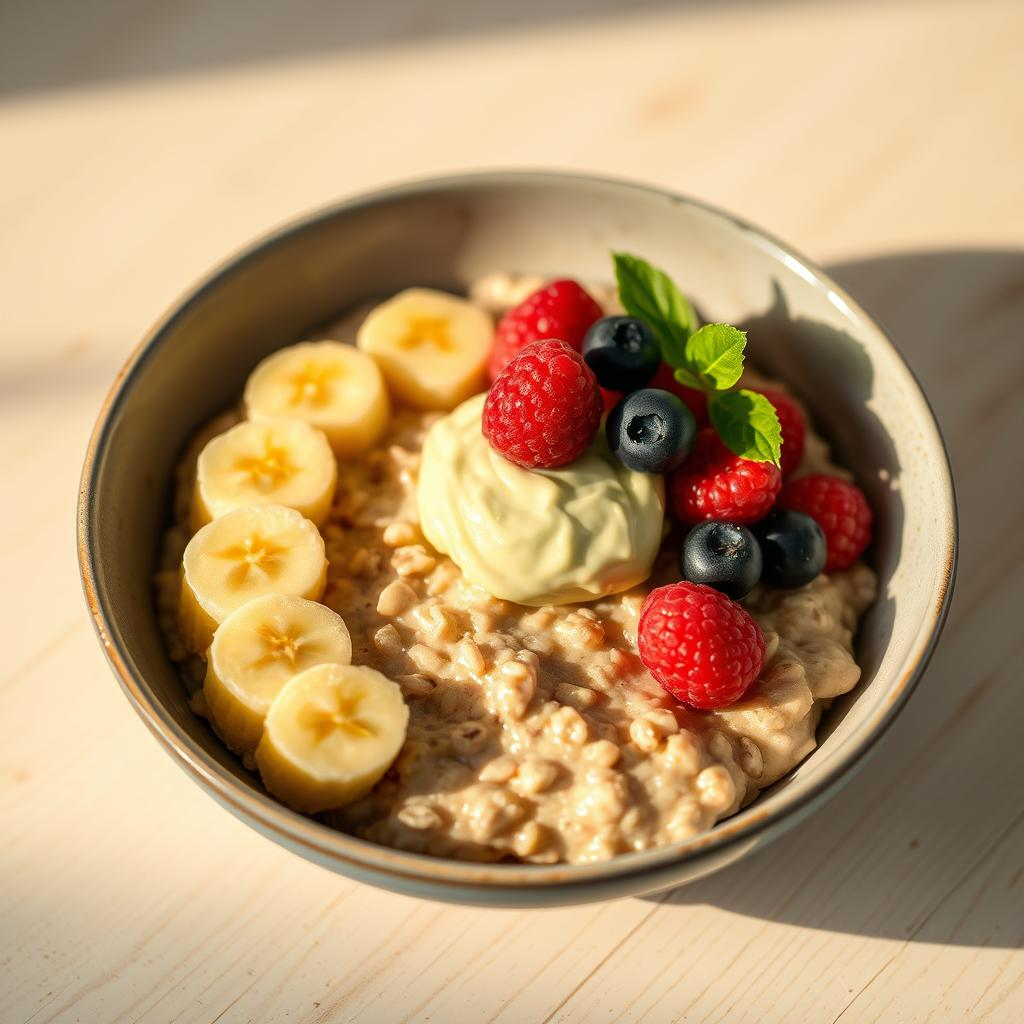


🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 
 🦦 Nutria — Procesando perfil del paciente
  Condición: diabetes tipo 2 con hipertensión arterial
  Alergias: gluten
  Prohibiciones: azúcar refinada, sal, harina de trigo, arroz blanco
  Preferencias: cocina latinoamericana, especias aromáticas
🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 

Consultando a Llama 3 para generar la receta...
 Receta generada (2811 caracteres).
 Generando imagen del plato con FLUX.1-schnell...
Imagen generada (1024x1024 px).

 RESULTADO DE 🦦Nutria 



---
## Pollo con Arroz Integral y Verduras a la Parrilla
**Seguro para:** diabetes tipo 2 · hipertensión arterial
**Tiempo:** 40 min | **Porciones:** 4 | **Calorías:** ~520 kcal | **Textura:** jugosa y crujiente

### Alertas de seguridad verificadas
- 100% libre de gluten (arroz integral + especias sin gluten)
- Sin azúcar refinada (usando edulcorante natural de la fruta)
- Sin sal (usando hierbas aromáticas para sabor)
- Sin harina de trigo (arroz integral)
- Sin arroz blanco (usando arroz integral)

### Ingredientes
**Base:**
- 250g arroz integral cocido al vapor (sin gluten)
- 2 cdas. jugo de naranja recién exprimido (sin azúcar añadida)

**Proteína:**
- 4 pechugas de pollo sin piel (sin sal)
- 2 cdas. aceite de oliva extra virgen

**Verduras:**
- 1 zanahoria grande, pelada y cortada en rodajas
- 1 pimiento rojo grande, cortado en cubos
- 1 cebolla grande, cortada en rodajas
- 2 dientes de ajo, picados

**Sabor:**
- 1 cdta. comino molido (sin gluten)
- 1 cdta. orégano seco (sin gluten)
- 1 cdta. pimienta negra (sin gluten)

**Decoración:**
- Cilantro fresco picado (sin gluten)
- Limón en rodajas (sin azúcar añadida)

### Preparación Paso a Paso

**1. Cocinar el arroz (20 min)**
Lavar el arroz integral 3 veces hasta que el agua salga clara. Cocinar con vapor durante 15-18 min. Reposar 5 min. Mezclar con jugo de naranja recién exprimido.

**2. Pollo a la parrilla (15 min)**
Calentar la parrilla a fuego medio-alto. Colocar las pechugas de pollo y cocinar 7-8 min por lado. La carne debe quedar opaca pero aún jugosa. No agregar sal.

**3. Verduras a la parrilla (10 min)**
Colocar las rodajas de zanahoria, pimiento rojo y cebolla en la parrilla. Cocinar 5-6 min por lado. La verdura debe quedar crujiente pero no quemada.

**4. Armado del plato (presentación sensorial)**
En un plato amplio y de bordes bajos:
- Capa 1: Arroz integral extendido como base
- Capa 2: Pollo desmenuzado sobre el arroz
- Capa 3: Verduras a la parrilla en rodajas y cubos
- Sabor: Espolvorear comino, orégano y pimienta negra sobre el pollo
- Decoración: Cilantro fresco picado y limón en rodajas

### Beneficios Nutricionales por Condición
| Condición | Beneficio de esta receta |
| Diabetes tipo 2 | Arroz integral (fibra soluble) y verduras (fibra soluble) regulan el azúcar en sangre |
| Hipertensión arterial | Pollo bajo en grasa y sal, verduras ricas en potasio y fibra ayudan a reducir la presión arterial |

### Prompt Visual (en inglés para generación de imagen)
Professional food photography, a vibrant grilled chicken breast on a bed of brown rice,
colorful bell pepper and carrot slices, a sprinkle of fresh cilantro, a squeeze of lime,
pale wooden table, minimalist Latin American aesthetic, shallow depth of field, fresh and
appetizing, no added salt or sugar, 8K resolution, Michelin star plating
---


Imagen realista del plato:


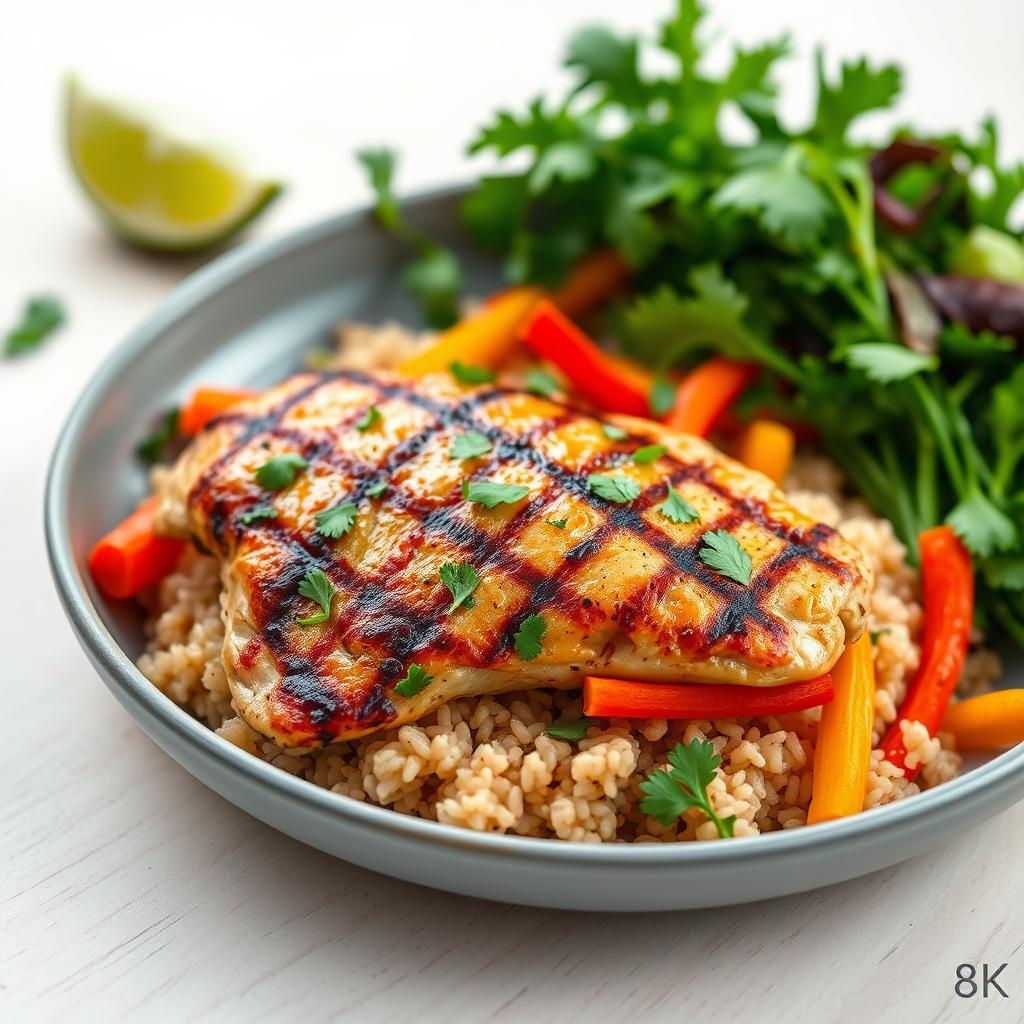


🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 
 🦦 Nutria — Procesando perfil del paciente
  Condición: hipotiroidismo con sobrepeso
  Alergias: ninguna
  Prohibiciones: soja cruda, coles crudas (brócoli, coliflor crudos), alimentos ultraprocesados
  Preferencias: sabores suaves y reconfortantes, fácil de preparar
🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 🦦🥗 

Consultando a Llama 3 para generar la receta...
 Receta generada (2463 caracteres).
 Generando imagen del plato con FLUX.1-schnell...
Imagen generada (1024x1024 px).

 RESULTADO DE 🦦Nutria 



---
## Receta: Pollo al Horno con Puré de Papas y Zanahorias

**Seguro para:** hipotiroidismo · sobrepeso
**Tiempo:** 45 min | **Porciones:** 4 | **Calorías:** ~550 kcal | **Textura:** suave y cremosa

### Alertas de seguridad verificadas
- Libre de soja cruda (pollo y verduras cocidas)
- Sin coles crudas (zanahorias cocidas)
- Sin alimentos ultraprocesados (ingredientes frescos y naturales)
- Textura homogénea, apta para sensibilidad sensorial

### Ingredientes
**Proteína:**
- 1 pollo entero sin piel (~1.5 kg), cortado en 4 piezas
- 2 cdas. aceite de oliva extra virgen

**Cremoso:**
- 4 papas (~1 kg), peladas y cortadas en cubos
- 2 zanahorias (~200g), peladas y cortadas en cubos
- 1 cdita. aceite de oliva extra virgen
- 1 cdita. crema de leche (opcional, para reducir la grasa)

**Sabor:**
- 2 cdas. aceite de oliva extra virgen
- 1 cdita. sal
- 1/2 cdita. pimienta negra
- 1/4 cdita. orégano seco

**Decoración:**
- Pimienta negra fresca
- Orégano fresco

### Preparación Paso a Paso

**1. Cocinar el pollo (20 min)**
Precalentar el horno a 180°C. Colocar el pollo en una bandeja para hornear. Mezclar aceite de oliva, sal, pimienta y orégano. Untar la mezcla sobre el pollo. Hornear 20 min o hasta que esté cocido.

**2. Puré de Papas y Zanahorias (25 min)**
Colocar las papas y zanahorias en una olla grande con agua. Cocinar a fuego alto hasta que estén tiernas. Escurrir y machacar con tenedor hasta obtener puré liso. Agregar aceite de oliva y crema de leche (si se usa). Mezclar bien.

**3. Armado del plato (presentación sensorial)**
En un plato amplio y de bordes bajos:
- Capa 1: Puré de papas y zanahorias extendido como base cremosa
- Capa 2: Pollo al horno desmenuzado sobre el puré
- Decoración: Pimienta negra fresca y orégano fresco

### Beneficios Nutricionales por Condición
| Condición | Beneficio de esta receta |
| Hipotiroidismo | Cocción suave y bajo calor: no estimula el metabolismo |
| Sobrepeso | Proteínas magras (pollo) y fibra (papas y zanahorias) |
| AACC | Plato estructurado visualmente, estimulante pero no abrumador |

### Prompt Visual (en inglés para generación de imagen)
Professional food photography, a warm and inviting plate with tender chicken chunks,
creamy sweet potato and carrot mash, soft golden lighting, pale wooden table,
minimalist rustic aesthetic, shallow depth of field, fresh and appetizing, no spice,
gentle colors — beige chicken, orange carrots, creamy mash, 8K resolution,
Michelin star plating.
---


Imagen realista del plato:


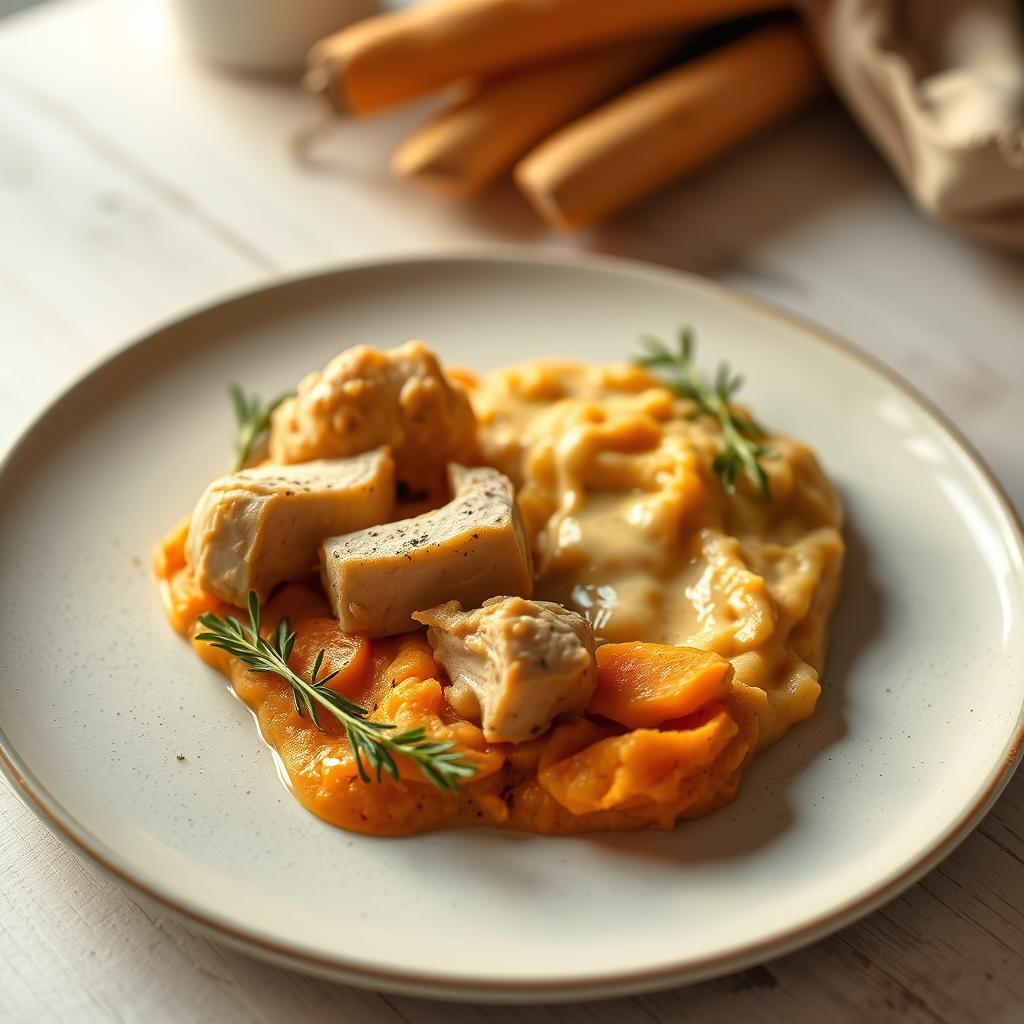

In [8]:
# MODIFICA ESTOS VALORES CON EL PERFIL DEL PACIENTE

MI_CONDICION    = "hipertencion"  # Obligatorio
MIS_ALERGIAS    = "maní"  # Opcional ('ninguna' si no aplica)
MIS_PROHIBICIONES = "grasa, sodio"
MIS_PREFERENCIAS = "dulce, suave"

# Ejecutamos la aplicación completa
resultado = nutria(
    condicion     = MI_CONDICION,
    alergias      = MIS_ALERGIAS,
    prohibiciones = MIS_PROHIBICIONES,
    preferencias  = MIS_PREFERENCIAS
)
# Segundo ejemplo

resultado_2 = nutria(
    condicion     = "diabetes tipo 2 con hipertensión arterial",
    alergias      = "gluten",
    prohibiciones = "azúcar refinada, sal, harina de trigo, arroz blanco",
    preferencias  = "cocina latinoamericana, especias aromáticas"
)
# Tercer ejemplo

resultado_3 = nutria(
    condicion     = "hipotiroidismo con sobrepeso",
    alergias      = "ninguna",
    prohibiciones = "soja cruda, coles crudas (brócoli, coliflor crudos), alimentos ultraprocesados",
    preferencias  = "sabores suaves y reconfortantes, fácil de preparar"
)


##**Parte 8**
###Guardar resultados

In [9]:
def guardar_resultados(resultado, receta="receta_nutria"):
    """
    Guarda la receta en un archivo .txt y la imagen en un archivo .png.

    Permite al usuario descargar los resultados generados por 🦦 Nutria
    desde el panel de archivos de Colab (ícono de carpeta en el panel izquierdo).

    Parámetros:
        resultado (dict): Diccionario retornado por nutria() con 'receta' e 'imagen'.
        nombre_archivo (str): Prefijo del nombre de archivo sin extensión.
    """
    if resultado is None:
        print("No hay resultados para guardar.")
        return

    # Guardar texto de la receta
    ruta_texto = f"{receta}.txt"
    with open(ruta_texto, "w", encoding="utf-8") as f:
        f.write(resultado["receta"])
    print(f"Receta guardada en: {ruta_texto}")

    # Guardar imagen si existe
    if resultado["imagen"] is not None:
        ruta_imagen = f"{receta}.png"
        resultado["imagen"].save(ruta_imagen)
        print(f"Imagen guardada en: {ruta_imagen}")

    print("\nPuedes descargar los archivos desde el panel de Archivos.")


# Guardamos el primer resultado si existe
if resultado:
    guardar_resultados(resultado, "receta")

Receta guardada en: receta.txt
Imagen guardada en: receta.png

Puedes descargar los archivos desde el panel de Archivos.


##**Parte 9**
###Interfaz

In [13]:
CARPETA_DRIVE = "/content/drive/MyDrive/Nutria"
print(os.listdir(CARPETA_DRIVE))

['app.py', 'index.html']


In [12]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

# Cambia esta ruta por la carpeta donde los subiste en tu Drive
CARPETA_DRIVE = "/content/drive/MyDrive/Nutria"   # ← ajusta el nombre

shutil.copy(f"{CARPETA_DRIVE}/app.py",      "/content/app.py")
shutil.copy(f"{CARPETA_DRIVE}/index.html",  "/content/index.html")

print("Archivos copiados a /content/ correctamente")

Mounted at /content/drive
Archivos copiados a /content/ correctamente


In [14]:
!pip install fastapi uvicorn nest-asyncio --quiet

import os, threading, nest_asyncio
import uvicorn
from google.colab import userdata, output
os.system("fuser -k 8000/tcp")

import time
time.sleep(1)

nest_asyncio.apply()

# 2. Pasar la API Key al entorno (usa el mismo Secret del notebook)
os.environ["Nutri_IA"] = userdata.get("Nutri_IA")

# 3. Importar la app (app.py e index.html deben estar subidos en /content/)
import sys
sys.path.insert(0, "/home")
from app import app as nutria_app

# 4. Arrancar el servidor en un hilo separado (no bloquea el notebook)
def iniciar_servidor():
    uvicorn.run(nutria_app, host="0.0.0.0", port=8000, log_level="error")

hilo = threading.Thread(target=iniciar_servidor, daemon=True)
hilo.start()

# Esperar un momento a que el servidor arranque
import time
time.sleep(2)

# 5. Obtener la URL pública usando el tunnel integrado de Colab
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8000)")

print("=" * 60)
print("🦦 Nutria — SITIO WEB ACTIVO")
print("=" * 60)
print(f"\nAbre esta URL en tu navegador:\n\n   {url}\n")
print("La URL funciona mientras esta celda esté ejecutándose.")
print("Cualquier persona con el link puede usarla.")
print("=" * 60)

🦦 Nutria — SITIO WEB ACTIVO

Abre esta URL en tu navegador:

   https://8000-gpu-t4-s-kkb-usw4b0-3v8nl73ebaj5-b.us-west4-0.prod.colab.dev

La URL funciona mientras esta celda esté ejecutándose.
Cualquier persona con el link puede usarla.


## **Reflexion etica**
###**Consideraciones eticas de 🦦 Nutria**
**🦦 Nutria** genera recetas medicas nutricionales haciendo uso de inteligencia artificial, esto plantea responsabilidades éticas importantes
**Limitaciones clinicas y responsabilidad medica** 🦦Nutria es una herramiento, no reemplaza el  criterio de un nutricionista ni de un medico, la recetas generadas sirven para orientarse, sin embargo deben ser validadas por un profesional de la salud antes de que se opte por estas como algun tipo de "tratamiento", se incluye una advertencia al respecto, es fundamental que los usuarios comprendan que la IA no tiene acceso a ningun tipo de historial clinico del usuario, tampoco puede evaluar la interaccion de los alimentos con medicamentos que se esten consumiendo o a comorbilidades no declaradas

el modelo puede presental sesgos, ya que el modelo que se utiliza (Meta-Llama-3-8B-Instruct) fue entrenado principalmente con datos en ingles y datos de culturas occidentales, esto puede afectar las recomendaciones culinarias, privilegiando ingredientes menos accesibles en contextos latinoamericanos, además el sistema procesa informacion medica altamente sensible como lo son, diagnosticos, alergias, condiciones cronicas, es de gran importancia queningun dato personal se almacene en servidores de terceros sin consentimiento explicito, adicional a ello, los LLMs pueden generar informacion nutricional incorrecta con "confianza" futuras versiones deberian incorporar valizacion con bases de datos nutricionales verificadas para minimizar este riesgo, por otro lado, esta vercion implemente APIs accesibles, puesto que el uso de APIs de pago limita el acceso a personas de escasos recursos